# Offline FOGAS on Discretized Mountain Car

**Objective.** This notebook evaluates FOGAS in a continuous-control environment through a finite state abstraction. Position and velocity are discretized into a 20 x 20 grid with an absorbing goal state, while action-block RBF features provide a smoother representation for offline learning.

**Dataset protocol.** Tabular Q-learning first supplies a near-optimal behavior policy. A successful trajectory from that policy defines a reset distribution over useful phase-space regions. `GymDataBuffer` then combines nominal and trajectory-based resets, epsilon exploration, and random-policy mixing to create fixed datasets. Both state-change-only and all-environment-step conventions are analyzed.

**Evaluation.** FOGAS and linear FQI are trained on the same RBF dataset and compared by success and mean steps to the goal. The final section reads `data/results/mountainCar/grids/grid_mountaincar.csv`, generated by `../scripts/grid_mountaincar.py`, to study behavior mixture, exploration, and reset coverage across matched runs.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

def find_root(current_path):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "src" / "rl_methods").exists() and (parent / "data").exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results" / "mountainCar"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root found at: {PROJECT_ROOT}")

import math
import itertools
import imageio
import random
import re

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import gymnasium as gym

from tqdm import tqdm
from matplotlib.colors import ListedColormap, BoundaryNorm

from rl_methods.q_learning import run_q_learning

from rl_methods.mdp import (
    StateDiscretizer,
    ActionDiscretizer,
    FeaturesMDP,
    TabularFeatureMap,
)

from rl_methods.data_collection import (
    GymDataBuffer,
    DatasetAnalyzer,
)

from rl_methods.fogas import (
    FOGASSolver,
    FOGASOracleSolver,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)

from rl_methods.fqi import FQISolver

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed = 44
set_global_seed(seed)

DATASET_PATHROW = DATASETS_DIR / "mountaincar_row_data.csv"
DATASET_PATHCLEAN = DATASETS_DIR / "mountaincar_clean_data.csv"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Project root found at: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Using device: cpu


/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%pip install imageio


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Discretization design

We add one absorbing abstract state:
- `GOAL_STATE_ID`: successful termination (`position >= 0.5` and `velocity >= goal_velocity`)


In [3]:
ENV_ID = "MountainCar-v0"
GAMMA = 0.9
GOAL_POSITION = 0.5
GOAL_VELOCITY = 0.0
MIN_POSITION = -1.2
MAX_POSITION = 0.6
MAX_SPEED = 0.07
FORCE = 0.001
GRAVITY_COEFF = 0.0025
TIME_LIMIT = 200

STATE_BINS = np.array([20, 20], dtype=np.int64)
OBS_LOW = np.array([MIN_POSITION, -MAX_SPEED], dtype=np.float64)
OBS_HIGH = np.array([MAX_POSITION, MAX_SPEED], dtype=np.float64)

ACTION_IDS = np.array([0, 1, 2], dtype=np.int64)
ACTION_LABELS = {0: "left", 1: "coast", 2: "right"}

INITIAL_OBS_REFERENCE = np.array([-0.5, 0.0], dtype=np.float64)

state_disc = StateDiscretizer(
    low=OBS_LOW,
    high=OBS_HIGH,
    bins=STATE_BINS,
    terminal_obs_predicate=lambda obs: obs[0] >= GOAL_POSITION and obs[1] >= GOAL_VELOCITY,
)

action_disc = ActionDiscretizer(
    action_values=ACTION_IDS,
    action_labels=ACTION_LABELS,
)

CORE_STATE_COUNT = state_disc.core_state_count
GOAL_STATE_ID = state_disc.absorbing_state_id
N_STATES = state_disc.n_states
N_ACTIONS = action_disc.n_actions

states = torch.arange(N_STATES, dtype=torch.int64)
actions = torch.arange(N_ACTIONS, dtype=torch.int64)

BIN_EDGES = state_disc.bin_edges
BIN_CENTERS = state_disc.bin_centers

def obs_to_state_id_nonterminal(obs):
    return state_disc.multi_bin_to_state_id(state_disc.obs_to_multi_bin(obs))

clip_obs = state_disc.clip
is_goal_obs = state_disc.is_terminal_obs
obs_to_multi_bin = state_disc.obs_to_multi_bin
multi_bin_to_state_id = state_disc.multi_bin_to_state_id
state_id_to_multi_bin = state_disc.state_id_to_multi_bin
obs_to_state_id = obs_to_state_id_nonterminal
state_id_to_center_obs = state_disc.state_id_to_center_obs

action_id_to_label = action_disc.action_id_to_label

INITIAL_STATE_ID = obs_to_state_id(INITIAL_OBS_REFERENCE)

env = gym.make(ENV_ID, goal_velocity=GOAL_VELOCITY)
sampled_initial_obs, _ = env.reset(seed=seed)
env.close()

print(f"Sampled initial observation: {sampled_initial_obs}")
print(f"Reference initial observation: {INITIAL_OBS_REFERENCE}")
print(f"Reference initial abstract state id: {INITIAL_STATE_ID}")
print(f"Non-terminal abstract states: {CORE_STATE_COUNT}")
print(f"Total abstract states: {N_STATES}")
print(f"Discrete action ids: {ACTION_IDS}")
print(f"Action labels: {[action_id_to_label(int(a)) for a in ACTION_IDS]}")

Sampled initial observation: [-0.5754869  0.       ]
Reference initial observation: [-0.5  0. ]
Reference initial abstract state id: 150
Non-terminal abstract states: 400
Total abstract states: 401
Discrete action ids: [0 1 2]
Action labels: ['left', 'coast', 'right']


## Evaluation methods

These are specific of the policy and environment of MountainCar.

To be able to plot the policy:

In [4]:
def plot_policy(
    pi,
    state_disc,
    action_disc,
    title="Greedy Policy in MountainCar Phase Space",
    colors=("#440154", "#21918c", "#fde725"),
    figsize=(12, 7),
    draw_boundaries=True,
    ax=None,
):
    N_STATES = state_disc.n_states
    N_ACTIONS = action_disc.n_actions
    STATE_BINS = state_disc.bins
    BIN_CENTERS = state_disc.bin_centers
    BIN_EDGES = state_disc.bin_edges
    CORE_STATE_COUNT = state_disc.core_state_count
    state_id_to_multi_bin = state_disc.state_id_to_multi_bin
    action_labels = [action_disc.action_id_to_label(a) for a in range(N_ACTIONS)]
    
    if CORE_STATE_COUNT is None:
        CORE_STATE_COUNT = int(np.prod(STATE_BINS))

    # --- Greedy actions ---
    pi_mat = pi.reshape(N_STATES, N_ACTIONS)
    greedy_actions = torch.argmax(pi_mat, dim=1).cpu().numpy()

    # --- Fill policy grid ---
    policy_grid = np.full(tuple(STATE_BINS), fill_value=-1, dtype=np.int64)
    for s in range(CORE_STATE_COUNT):
        i, j = state_id_to_multi_bin(s)
        policy_grid[i, j] = greedy_actions[s]

    # --- Colormap ---
    n_actions = len(action_labels)
    cmap = ListedColormap(list(colors)[:n_actions])
    norm = BoundaryNorm(
        [-0.5 + k for k in range(n_actions + 1)], cmap.N
    )

    # --- Figure / Axes ---
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = None

    X, V = np.meshgrid(BIN_CENTERS[0], BIN_CENTERS[1], indexing="ij")

    pcm = ax.pcolormesh(
        BIN_EDGES[0],
        BIN_EDGES[1],
        policy_grid.T,
        cmap=cmap,
        norm=norm,
        shading="flat",
    )

    if draw_boundaries:
        for a in range(n_actions - 1):
            ax.contour(
                X, V,
                (policy_grid == a).astype(float),
                levels=[0.5],
                linewidths=1.2,
            )

    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(title)

    target_fig = fig if own_fig else ax.get_figure()
    cbar = target_fig.colorbar(pcm, ax=ax, ticks=list(range(n_actions)))
    cbar.ax.set_yticklabels(list(action_labels))

    if own_fig:
        plt.tight_layout()
        plt.show()

    return fig, ax

To be able to evaluate in how many steps the policy finds goal and also can render the solution to GIf

In [5]:
def evaluate_and_save_gif(
    policy,
    state_disc,
    action_disc,
    filename,
    env_id=ENV_ID,
    fps=30,
    seed=seed,
):
    """
    Evaluate a policy in the environment and save a GIF.

    Args:
        policy: Tensor/array of shape (N_STATES, N_ACTIONS) or (N_STATES,).
        state_disc: BoxStateDiscretizer.
        action_disc: DiscreteActionDiscretizer.
        filename: Output GIF path.
        env_id: Gymnasium environment ID.
        fps: Frames per second.
    """
    print(f"Starting simulation for {filename}...")

    is_distribution = (len(policy.shape) == 2)

    test_env = gym.make(env_id, render_mode="rgb_array", goal_velocity=GOAL_VELOCITY)
    obs, info = test_env.reset(seed=seed)

    total_reward = 0.0
    steps = 0
    done = False
    frames = [test_env.render()]

    while not done:
        state_id = state_disc.obs_to_state_id(obs)

        if is_distribution:
            if hasattr(policy, "detach"):
                action_id = int(torch.argmax(policy[state_id]))
            else:
                action_id = int(np.argmax(policy[state_id]))
        else:
            action_id = int(policy[state_id])

        env_action = action_disc.action_id_to_env_action(action_id)

        obs, reward, terminated, truncated, info = test_env.step(env_action)
        frames.append(test_env.render())

        total_reward += reward
        steps += 1
        done = terminated or truncated

    test_env.close()

    status = "Success! Reached goal" if terminated else "Failed (Time Limit)"
    print(f"{status} in {steps} steps. Total Reward: {total_reward}")

    print(f"Saving GIF to {filename}...")
    imageio.mimsave(filename, frames, fps=fps)
    print("Done!")

In [6]:
def evaluate_policy_mean_steps(
    policy,
    state_disc,
    action_disc,
    env_id=ENV_ID,
    n_trials=5,
    max_steps=200,
    seed=seed,
):
    """
    Simulate a policy multiple times and return mean steps.

    Args:
        policy: Tensor/array of shape (N_STATES, N_ACTIONS) or (N_STATES,).
        state_disc: BoxStateDiscretizer.
        action_disc: DiscreteActionDiscretizer.
        env_id: Gymnasium environment ID.
        n_trials: Number of trials.
        max_steps: Max steps per episode.

    Returns:
        float: Mean number of steps.
    """
    is_distribution = (len(policy.shape) == 2)
    test_env = gym.make(env_id, max_episode_steps=max_steps, goal_velocity=GOAL_VELOCITY)

    total_steps_list = []

    for trial in range(n_trials):
        obs, _ = test_env.reset(seed=seed + trial)
        done = False
        steps = 0

        while not done:
            state_id = state_disc.obs_to_state_id(obs)

            if is_distribution:
                if hasattr(policy, "detach"):
                    action_id = int(torch.argmax(policy[state_id]))
                else:
                    action_id = int(np.argmax(policy[state_id]))
            else:
                action_id = int(policy[state_id])

            env_action = action_disc.action_id_to_env_action(action_id)

            obs, reward, terminated, truncated, _ = test_env.step(env_action)
            steps += 1
            done = terminated or truncated

        total_steps_list.append(steps)

    test_env.close()

    mean_steps = sum(total_steps_list) / n_trials
    success_count = sum(1 for s in total_steps_list if s < max_steps)

    print(
        f"Evaluation over {n_trials} trials: "
        f"Mean Steps = {mean_steps:.2f} ({success_count}/{n_trials} reached goal)"
    )

    return mean_steps

To be able to print state-action of the policy with probabilities

In [7]:
def print_policy_rows(
    policy,
    state_disc,
    action_disc,
    compare_policy=None,
    include_goal=False,
    decimals=3,
):
    N_STATES = state_disc.n_states
    N_ACTIONS = action_disc.n_actions
    CORE_STATE_COUNT = state_disc.core_state_count
    GOAL_STATE_ID = state_disc.absorbing_state_id

    policy = torch.as_tensor(policy, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).cpu()

    compare = None
    if compare_policy is not None:
        compare = torch.as_tensor(compare_policy, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).cpu()

    max_state = N_STATES if include_goal else CORE_STATE_COUNT

    print()
    print("Policy rows")
    print("Legend:", [action_disc.action_id_to_label(a) for a in range(N_ACTIONS)])
    if compare is not None:
        print("Format: main policy | compare policy")
    print()

    for s in range(max_state):
        obs = state_disc.state_id_to_center_obs(s)

        if obs is None:
            pos_str = "nan"
            vel_str = "nan"
        else:
            pos_str = f"{obs[0]: .3f}"
            vel_str = f"{obs[1]: .3f}"

        probs = policy[s].numpy()
        probs_str = "[" + ", ".join(f"{p:.{decimals}f}" for p in probs) + "]"
        greedy_main = action_disc.action_id_to_label(int(torch.argmax(policy[s]).item()))

        line = (
            f"s={s:3d}  "
            f"pos={pos_str:>7}  vel={vel_str:>7}  "
            f"pi={probs_str}  "
            f"argmax={greedy_main}"
        )

        if compare is not None:
            probs_cmp = compare[s].numpy()
            probs_cmp_str = "[" + ", ".join(f"{p:.{decimals}f}" for p in probs_cmp) + "]"
            greedy_cmp = action_disc.action_id_to_label(int(torch.argmax(compare[s]).item()))
            same = torch.argmax(policy[s]).item() == torch.argmax(compare[s]).item()
            mark = "same" if same else "DIFF"
            line += f"   |   cmp={probs_cmp_str}  argmax={greedy_cmp}  -> {mark}"

        print(line)

## MDP construction

In [8]:
states = torch.arange(state_disc.n_states, dtype=torch.int64)
actions = torch.arange(action_disc.n_actions, dtype=torch.int64)

phi_tabular = TabularFeatureMap(
    n_states=state_disc.n_states,
    n_actions=action_disc.n_actions,
)

mdp = FeaturesMDP(
    states=states,
    actions=actions,
    phi=phi_tabular,
    gamma=GAMMA ** 5,
    x0=state_disc.obs_to_state_id(INITIAL_OBS_REFERENCE),
    omega=None,
)

In [ ]:
RBF_BINS = np.array([15, 15], dtype=np.int64)

RBF_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, RBF_BINS)
]
RBF_GRID_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in RBF_EDGES]
RBF_CENTERS = np.array(list(itertools.product(*RBF_GRID_CENTERS)), dtype=np.float64)

K_CENTERS = len(RBF_CENTERS)

width_position = (MAX_POSITION - MIN_POSITION) / RBF_BINS[0]
width_velocity = (MAX_SPEED - (-MAX_SPEED)) / RBF_BINS[1]
VARIANCE_SCALE = 0.05
SIGMA_SQUARED = np.array(
    [width_position**2, width_velocity**2],
    dtype=np.float64,
) * VARIANCE_SCALE

D_RBF = K_CENTERS * action_disc.n_actions

def phi_rbf(state_id, action_id):
    obs = state_disc.state_id_to_center_obs(state_id)

    if obs is None:
        return torch.zeros(D_RBF, dtype=torch.float64)

    diff_sq = (RBF_CENTERS - obs) ** 2
    f_x = np.exp(-0.5 * np.sum(diff_sq / SIGMA_SQUARED, axis=1))

    feat = np.zeros(D_RBF, dtype=np.float64)
    start_idx = int(action_id) * K_CENTERS
    end_idx = start_idx + K_CENTERS
    feat[start_idx:end_idx] = f_x

    return torch.from_numpy(feat)

print(f"Number of RBF centers (k): {K_CENTERS}")
print(f"Total feature dimension (d): {D_RBF}")

Number of RBF centers (k): 225
Total feature dimension (d): 675


In [10]:
mdp_rbf = FeaturesMDP(
    states=states,
    actions=actions,
    phi=phi_rbf,
    gamma=GAMMA ** 5,
    x0=state_disc.obs_to_state_id(INITIAL_OBS_REFERENCE),
    omega=None,
)

## Q-Learning solving

With linear decay, that is necessary.

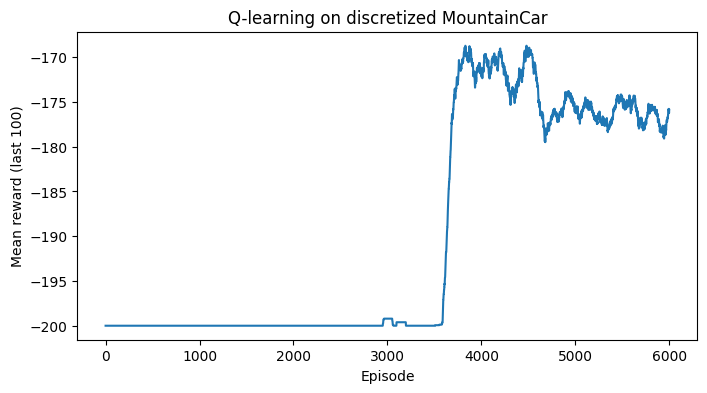

Initial state greedy action: right
Q(initial state): tensor([-10.0000, -10.0000,  -9.9988], dtype=torch.float64)


In [11]:
q_star_ql, greedy_actions_ql, rewards_ql = run_q_learning(
    episodes=6000,
    alpha=0.9,
    gamma=0.9,
    epsilon_start=1.0,
    render=False,
    seed=seed,
    env_id=ENV_ID,
    env_kwargs={"goal_velocity": GOAL_VELOCITY},
    obs_to_state_id=obs_to_state_id,
    n_states=N_STATES,
    n_actions=N_ACTIONS,
    terminal_state_id=GOAL_STATE_ID,
    initial_state_id=INITIAL_STATE_ID,
    action_id_to_label=action_id_to_label,
    plot=True,
    plot_title="Q-learning on discretized MountainCar",
)

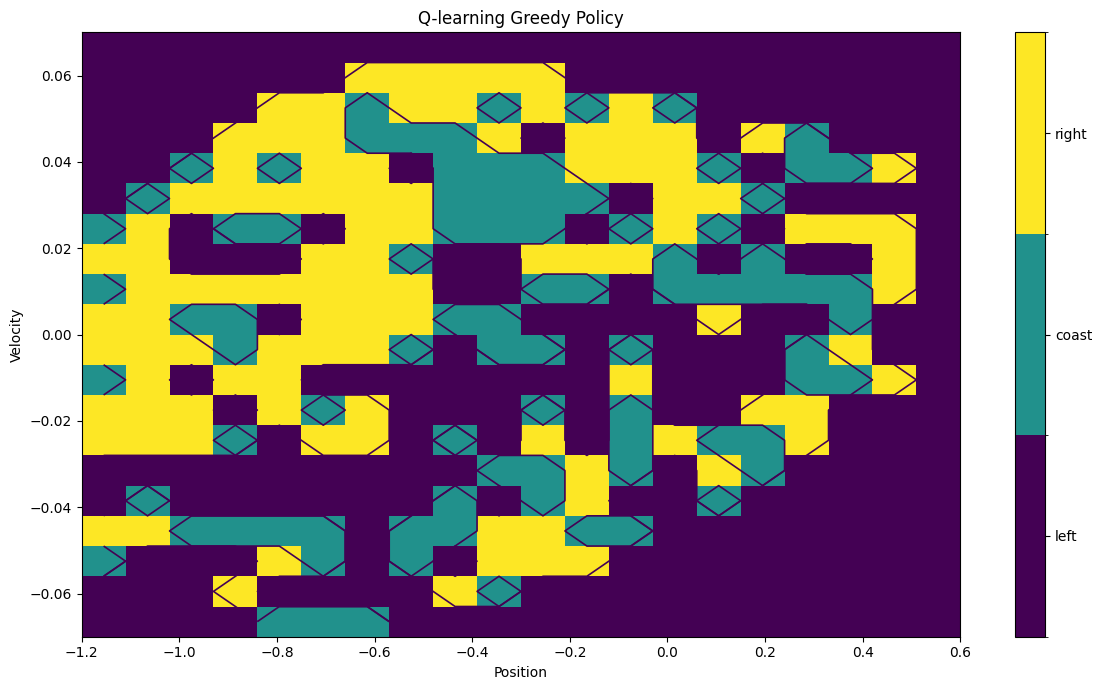

Starting simulation for /shared/home/mauro.diaz/work/FOGAS/data/results/mountain_car_q_learning.gif...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Success! Reached goal in 183 steps. Total Reward: -183.0
Saving GIF to /shared/home/mauro.diaz/work/FOGAS/data/results/mountain_car_q_learning.gif...
Done!


In [12]:
# From learned Q-table -> greedy deterministic policy matrix
greedy_actions_ql = torch.argmax(q_star_ql, dim=1)

pi_matrix_ql = torch.zeros((N_STATES, N_ACTIONS), dtype=torch.float64)
pi_matrix_ql[torch.arange(N_STATES), greedy_actions_ql] = 1.0

# Optional: make goal state uniform instead of one-hot
pi_matrix_ql[GOAL_STATE_ID] = 1.0 / N_ACTIONS

plot_policy(
    pi_matrix_ql,
    state_disc,
    action_disc,
    title="Q-learning Greedy Policy",
)

evaluate_and_save_gif(
    pi_matrix_ql,
    state_disc,
    action_disc,
    RESULTS_DIR / "mountain_car_q_learning.gif",
)

## Dataset Collection

Personalized dataset collection using the environment of gym, macro steps etc...

As we cant compute the occupancy as in grid, here we compute a trajectory of the optimal policy and that will be our occupancy.

In [13]:
trajectory_state_ids, trajectory_reset_distribution, trajectory_steps = (
    GymDataBuffer.create_distribution(
        policy_matrix=pi_matrix_ql,
        state_disc=state_disc,
        action_disc=action_disc,
        env_id=ENV_ID,
        start_obs=INITIAL_OBS_REFERENCE,
        max_steps=TIME_LIMIT,
        seed=seed,
        goal_velocity=GOAL_VELOCITY,
    )
)

#### Collection with only state change

Compute the dataset:

In [14]:
df = GymDataBuffer.collect(
    policy_matrix=pi_matrix_ql,
    state_disc=state_disc,
    action_disc=action_disc,
    env_id=ENV_ID,
    n_transitions=25_000,
    epsilon=0.4,
    proportions=(0.8, 0.2),
    episode_based=True,
    max_steps_per_episode=200,
    reset_probs={"x0": 0.1, "custom": 0.9},
    custom_reset_distribution=trajectory_reset_distribution,
    reset_obs_mode="uniform_in_bin",
    seed=seed,
    save_path=DATASET_PATHCLEAN,
    verbose=True,
    drop_self_transitions=False,
    start_obs=INITIAL_OBS_REFERENCE,
    goal_velocity=GOAL_VELOCITY,
    wait_for_state_change=True,
)

Collected 25000 transitions over 405 episodes
Policy 0 (policy + epsilon exploration): 0.760
Policy 1 (random):                       0.240
Reset mode frequencies:
reset_mode
custom    0.91092
x0        0.08908
Name: proportion, dtype: float64
Saved dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/mountaincar_clean_data.csv


Dataset Analysis Summary
Source: /shared/home/mauro.diaz/work/FOGAS/data/datasets/mountaincar_clean_data.csv
Transitions: 25,000
Unique states: 287
Unique actions: 3
Unique pairs: 835
Coverage: 69.41%
Missing pairs: 368
Pair count min/mean/max: 0 / 20.78 / 166

State coverage: 286/400 (71.5%)
Unvisited states: 114


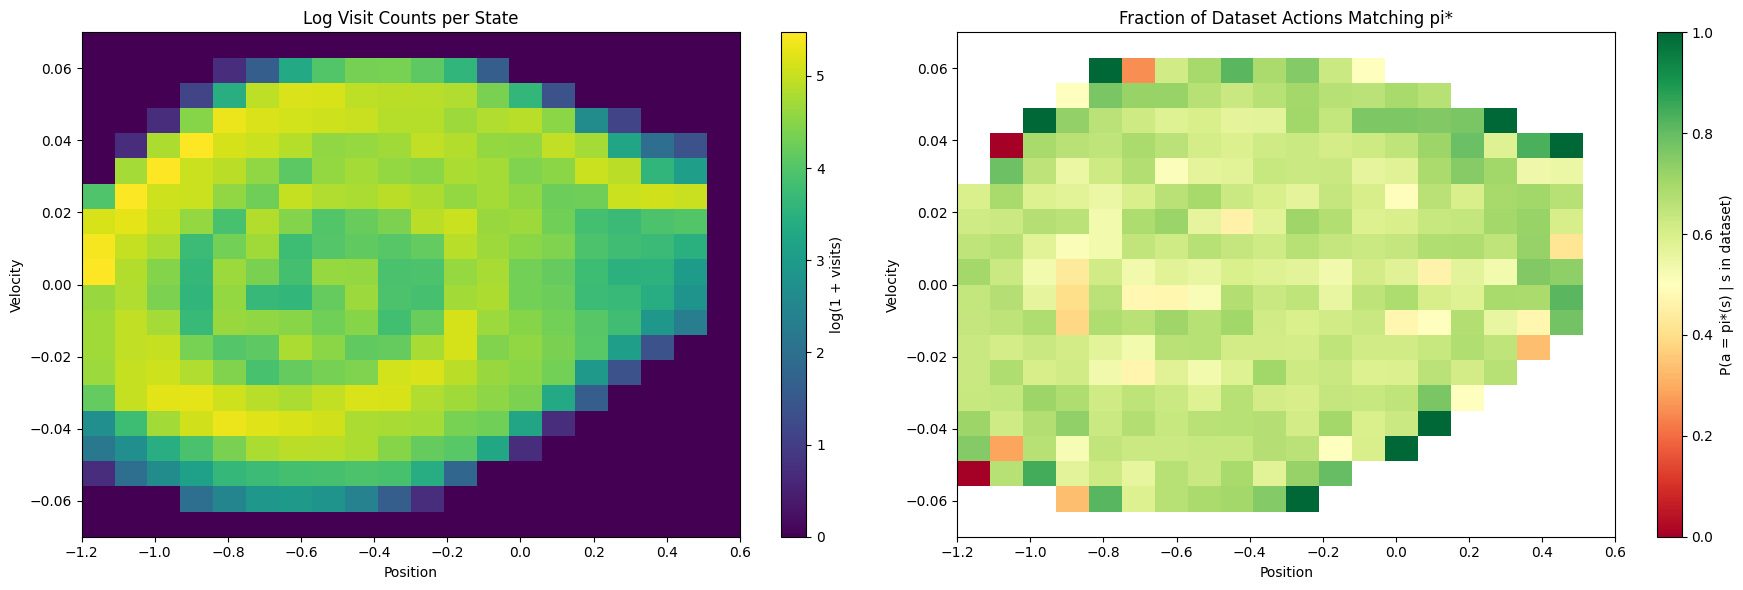

In [15]:
analyzer = DatasetAnalyzer(DATASET_PATHCLEAN)

analyzer.summary(
    n_states=state_disc.n_states,
    n_actions=action_disc.n_actions,
)

CORE_STATE_COUNT = state_disc.core_state_count
STATE_BINS = state_disc.bins
BIN_EDGES = state_disc.bin_edges

visited_states = set(df["state"].unique())
all_states = set(range(CORE_STATE_COUNT))
visited_core_states = visited_states & all_states
unvisited = all_states - visited_core_states

print(
    f"\nState coverage: {len(visited_core_states)}/{CORE_STATE_COUNT} "
    f"({100 * len(visited_core_states) / CORE_STATE_COUNT:.1f}%)"
)
print(f"Unvisited states: {len(unvisited)}")

visit_count_grid = np.zeros(tuple(STATE_BINS), dtype=np.int64)
optimal_match_grid = np.full(tuple(STATE_BINS), fill_value=np.nan)

greedy_actions = torch.argmax(
    torch.as_tensor(pi_matrix_ql, dtype=torch.float64).reshape(
        state_disc.n_states, action_disc.n_actions
    ),
    dim=1,
).cpu().numpy()

for s in all_states:
    i, j = state_disc.state_id_to_multi_bin(s)
    visit_count_grid[i, j] = analyzer.counts("states", s)

for s in visited_core_states:
    i, j = state_disc.state_id_to_multi_bin(s)
    total = analyzer.counts("states", s)
    on_policy = analyzer.counts("pairs", (s, int(greedy_actions[s])))
    optimal_match_grid[i, j] = on_policy / total if total > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

im0 = axes[0].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    np.log1p(visit_count_grid).T,
    cmap="viridis",
    shading="flat",
)
axes[0].set_title("Log Visit Counts per State")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Velocity")
fig.colorbar(im0, ax=axes[0], label="log(1 + visits)")

im1 = axes[1].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    optimal_match_grid.T,
    cmap="RdYlGn",
    shading="flat",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Fraction of Dataset Actions Matching pi*")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Velocity")
fig.colorbar(im1, ax=axes[1], label="P(a = pi*(s) | s in dataset)")

plt.tight_layout()
plt.show()

#### Collection with all the rows

In [16]:
df = GymDataBuffer.collect(
    policy_matrix=pi_matrix_ql,
    state_disc=state_disc,
    action_disc=action_disc,
    env_id=ENV_ID,
    n_transitions=40_000,
    epsilon=0.4,
    proportions=(0.8, 0.2),
    episode_based=True,
    max_steps_per_episode=200,
    reset_probs={"x0": 0.1, "custom": 0.9},
    custom_reset_distribution=trajectory_reset_distribution,
    reset_obs_mode="uniform_in_bin",
    seed=seed,
    save_path=DATASET_PATHROW,
    verbose=True,
    drop_self_transitions=False,
    start_obs=INITIAL_OBS_REFERENCE,
    goal_velocity=GOAL_VELOCITY,
    wait_for_state_change=False,
)

Collected 40000 transitions over 290 episodes
Policy 0 (policy + epsilon exploration): 0.751
Policy 1 (random):                       0.249
Reset mode frequencies:
reset_mode
custom    0.875
x0        0.125
Name: proportion, dtype: float64
Saved dataset to /shared/home/mauro.diaz/work/FOGAS/data/datasets/mountaincar_row_data.csv


Dataset Analysis Summary
Source: /shared/home/mauro.diaz/work/FOGAS/data/datasets/mountaincar_row_data.csv
Transitions: 40,000
Unique states: 285
Unique actions: 3
Unique pairs: 832
Coverage: 69.16%
Missing pairs: 371
Pair count min/mean/max: 0 / 33.25 / 317

State coverage: 284/400 (71.0%)
Unvisited states: 116


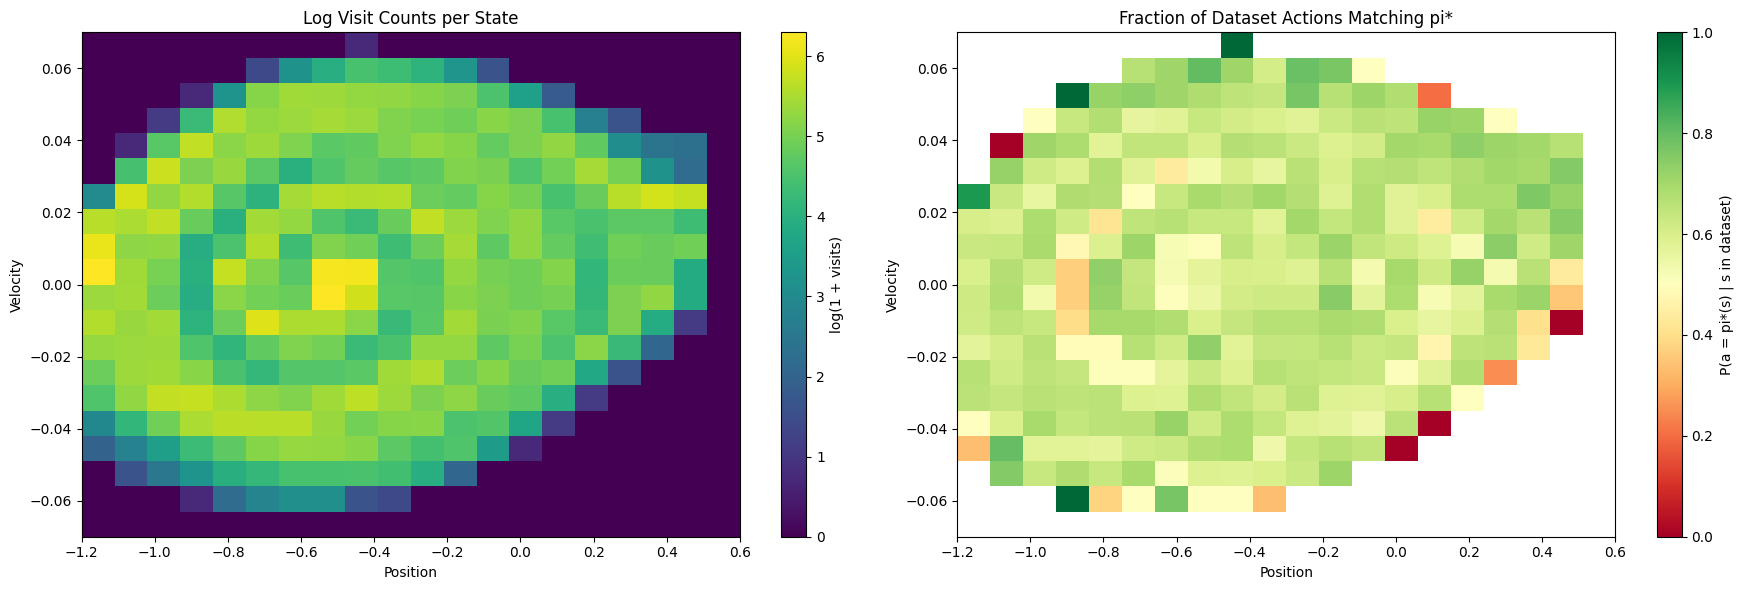

In [17]:
analyzer = DatasetAnalyzer(DATASET_PATHROW)

analyzer.summary(
    n_states=state_disc.n_states,
    n_actions=action_disc.n_actions,
)

CORE_STATE_COUNT = state_disc.core_state_count
STATE_BINS = state_disc.bins
BIN_EDGES = state_disc.bin_edges

visited_states = set(df["state"].unique())
all_states = set(range(CORE_STATE_COUNT))
visited_core_states = visited_states & all_states
unvisited = all_states - visited_core_states

print(
    f"\nState coverage: {len(visited_core_states)}/{CORE_STATE_COUNT} "
    f"({100 * len(visited_core_states) / CORE_STATE_COUNT:.1f}%)"
)
print(f"Unvisited states: {len(unvisited)}")

visit_count_grid = np.zeros(tuple(STATE_BINS), dtype=np.int64)
optimal_match_grid = np.full(tuple(STATE_BINS), fill_value=np.nan)

greedy_actions = torch.argmax(
    torch.as_tensor(pi_matrix_ql, dtype=torch.float64).reshape(
        state_disc.n_states, action_disc.n_actions
    ),
    dim=1,
).cpu().numpy()

for s in all_states:
    i, j = state_disc.state_id_to_multi_bin(s)
    visit_count_grid[i, j] = analyzer.counts("states", s)

for s in visited_core_states:
    i, j = state_disc.state_id_to_multi_bin(s)
    total = analyzer.counts("states", s)
    on_policy = analyzer.counts("pairs", (s, int(greedy_actions[s])))
    optimal_match_grid[i, j] = on_policy / total if total > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

im0 = axes[0].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    np.log1p(visit_count_grid).T,
    cmap="viridis",
    shading="flat",
)
axes[0].set_title("Log Visit Counts per State")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Velocity")
fig.colorbar(im0, ax=axes[0], label="log(1 + visits)")

im1 = axes[1].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    optimal_match_grid.T,
    cmap="RdYlGn",
    shading="flat",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Fraction of Dataset Actions Matching pi*")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Velocity")
fig.colorbar(im1, ax=axes[1], label="P(a = pi*(s) | s in dataset)")

plt.tight_layout()
plt.show()

## Solving it

Finally the last solved one (showed here) is with the mdp with RBF features and data without merging states!

In [22]:
solver = FOGASSolver(
    mdp=mdp,
    phi=mdp.phi,
    csv_path=DATASET_PATHROW,
    device=device,
    beta=1e-6,
    seed=seed,
)

# 1. Run the solver with your specific parameters
solver.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=20000,
)

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-06, n=40000)


FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [07:39<00:00, 43.50it/s]


tensor([[0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333],
        ...,
        [0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333],
        [0.3334, 0.3333, 0.3333]], device='cuda:0', dtype=torch.float64)

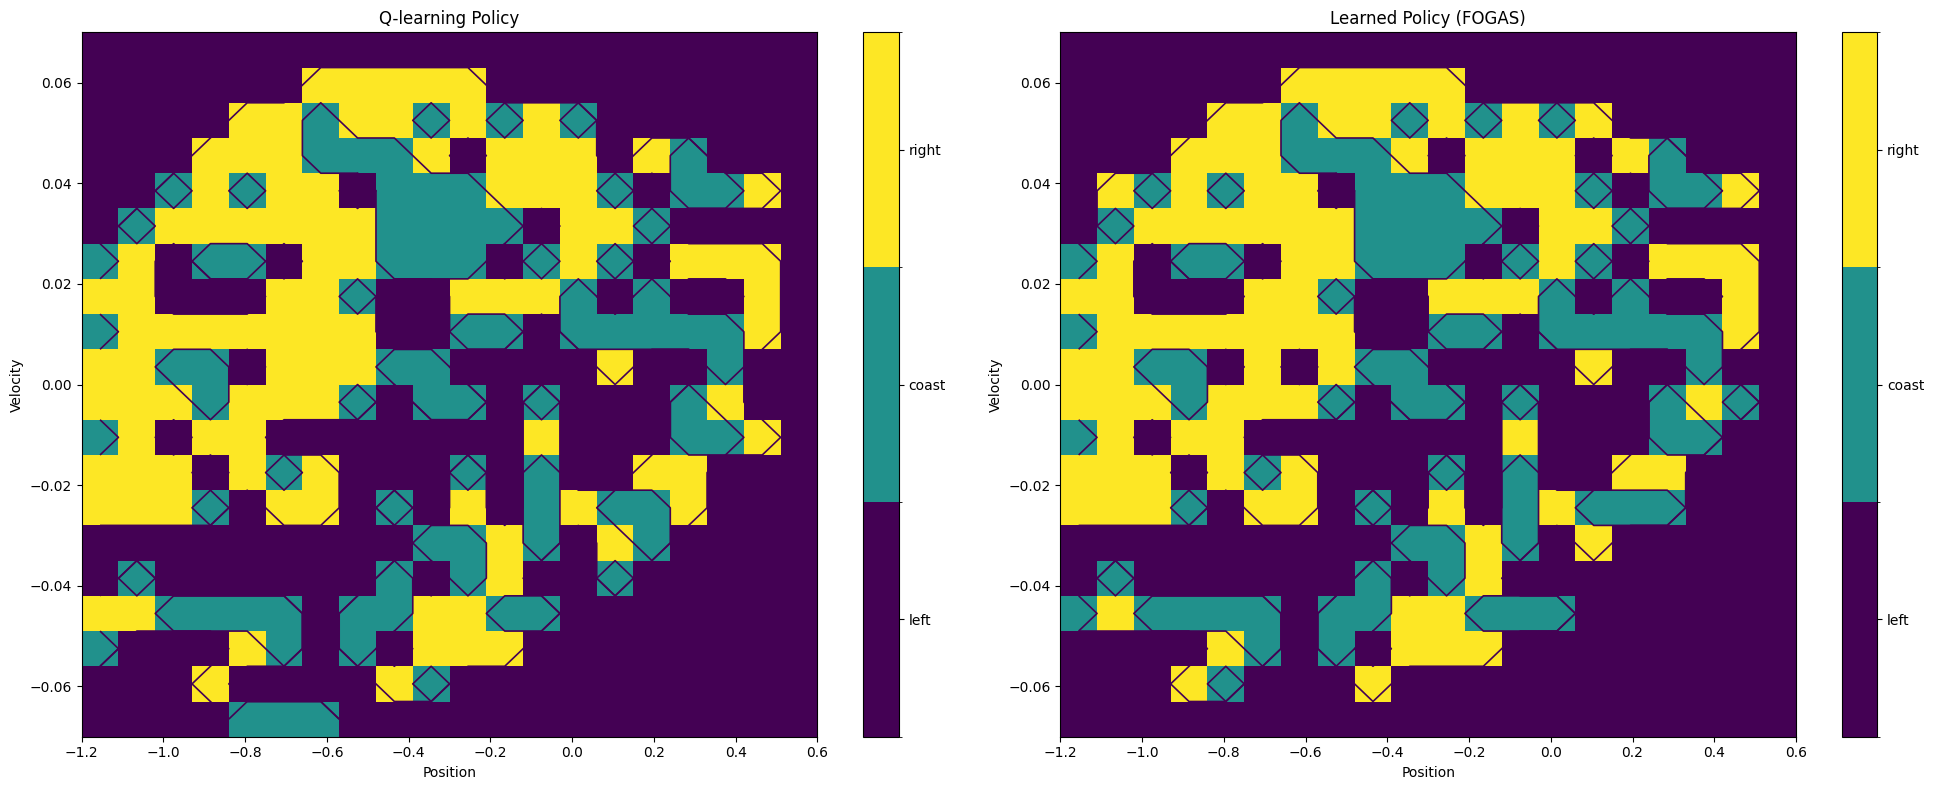

In [24]:
pi_solver = torch.as_tensor(
    solver.pi, dtype=torch.float64
).reshape(state_disc.n_states, action_disc.n_actions).detach().cpu()

pi_ql = torch.as_tensor(
    pi_matrix_ql, dtype=torch.float64
).reshape(state_disc.n_states, action_disc.n_actions).detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_policy(
    pi_ql,
    state_disc,
    action_disc,
    title="Q-learning Policy",
    ax=axes[0],
)

plot_policy(
    pi_solver,
    state_disc,
    action_disc,
    title="Learned Policy (FOGAS)",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

In [25]:
print_policy_rows(
    solver.pi,
    state_disc,
    action_disc,
    compare_policy=pi_ql,
)


Policy rows
Legend: ['left', 'coast', 'right']
Format: main policy | compare policy

s=  0  pos= -1.155  vel= -0.067  pi=[0.333, 0.333, 0.333]  argmax=left   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> same
s=  1  pos= -1.155  vel= -0.060  pi=[0.333, 0.333, 0.333]  argmax=left   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> same
s=  2  pos= -1.155  vel= -0.053  pi=[0.333, 0.333, 0.333]  argmax=left   |   cmp=[0.000, 1.000, 0.000]  argmax=coast  -> DIFF
s=  3  pos= -1.155  vel= -0.045  pi=[0.333, 0.334, 0.333]  argmax=coast   |   cmp=[0.000, 0.000, 1.000]  argmax=right  -> DIFF
s=  4  pos= -1.155  vel= -0.039  pi=[0.336, 0.334, 0.330]  argmax=left   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> same
s=  5  pos= -1.155  vel= -0.032  pi=[0.356, 0.322, 0.322]  argmax=left   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> same
s=  6  pos= -1.155  vel= -0.024  pi=[0.319, 0.316, 0.365]  argmax=right   |   cmp=[0.000, 0.000, 1.000]  argmax=right  -> same
s=  7  pos= -1.155  vel= -0.017  p

In [26]:
print("Evaluating Random Policy...")
run_1 = evaluate_policy_mean_steps(
    torch.zeros((state_disc.n_states, action_disc.n_actions)),
    state_disc,
    action_disc,
    n_trials=10,
)

print("Evaluating Solver Policy...")
run_2 = evaluate_policy_mean_steps(
    solver.pi,
    state_disc,
    action_disc,
    n_trials=10,
)

print(f"Improvement: {run_1 - run_2} fewer steps!")

Evaluating Random Policy...
Evaluation over 10 trials: Mean Steps = 200.00 (0/10 reached goal)
Evaluating Solver Policy...
Evaluation over 10 trials: Mean Steps = 179.70 (7/10 reached goal)
Improvement: 20.30000000000001 fewer steps!


## Grid Search

Loaded 210 rows from: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results/mountainCar/grids/grid_mountaincar.csv


,feature_type,reset_name,reset_probs,policy_fraction,random_fraction,epsilon,n_transitions,dataset_rows,status,error,...,fqi_solver_mean_steps,fqi_solver_successes,fqi_K,fqi_tau,fqi_ridge,fqi_augment_terminal_transitions,fqi_added_terminal_samples,fqi_final_theta_delta,fqi_status,fqi_error
0,rbf,x0_0_custom_100,"{""custom"": 1.0, ""x0"": 0.0}",1.0,0.0,0.0,25000,25000,ok,NaN,...,172.8,8,5000,0.1,0.01,True,0,1.528120e-14,ok,NaN
1,rbf,x0_0_custom_100,"{""custom"": 1.0, ""x0"": 0.0}",1.0,0.0,0.1,25000,25000,ok,NaN,...,183.9,5,5000,0.1,0.01,True,0,0.000000e+00,ok,NaN
2,rbf,x0_0_custom_100,"{""custom"": 1.0, ""x0"": 0.0}",1.0,0.0,0.2,25000,25000,ok,NaN,...,185.9,9,5000,0.1,0.01,True,0,0.000000e+00,ok,NaN
3,rbf,x0_0_custom_100,"{""custom"": 1.0, ""x0"": 0.0}",1.0,0.0,0.4,25000,25000,ok,NaN,...,194.9,4,5000,0.1,0.01,True,0,0.000000e+00,ok,NaN
4,rbf,x0_0_custom_100,"{""custom"": 1.0, ""x0"": 0.0}",1.0,0.0,0.6,25000,25000,ok,NaN,...,200.0,0,5000,0.1,0.01,True,0,0.000000e+00,ok,NaN


Plotted rows per curve:


curve
FOGAS greedy     210
FOGAS sampled    210
FQI greedy       210
Name: count, dtype: int64

,curve,epsilon,pi_star_percentage,x0_percentage,mean_steps
0,FOGAS greedy,0.0,100.0,0.0,177.7
1,FOGAS greedy,0.1,100.0,0.0,183.2
2,FOGAS greedy,0.2,100.0,0.0,167.3
3,FOGAS greedy,0.4,100.0,0.0,170.6
4,FOGAS greedy,0.6,100.0,0.0,171.9


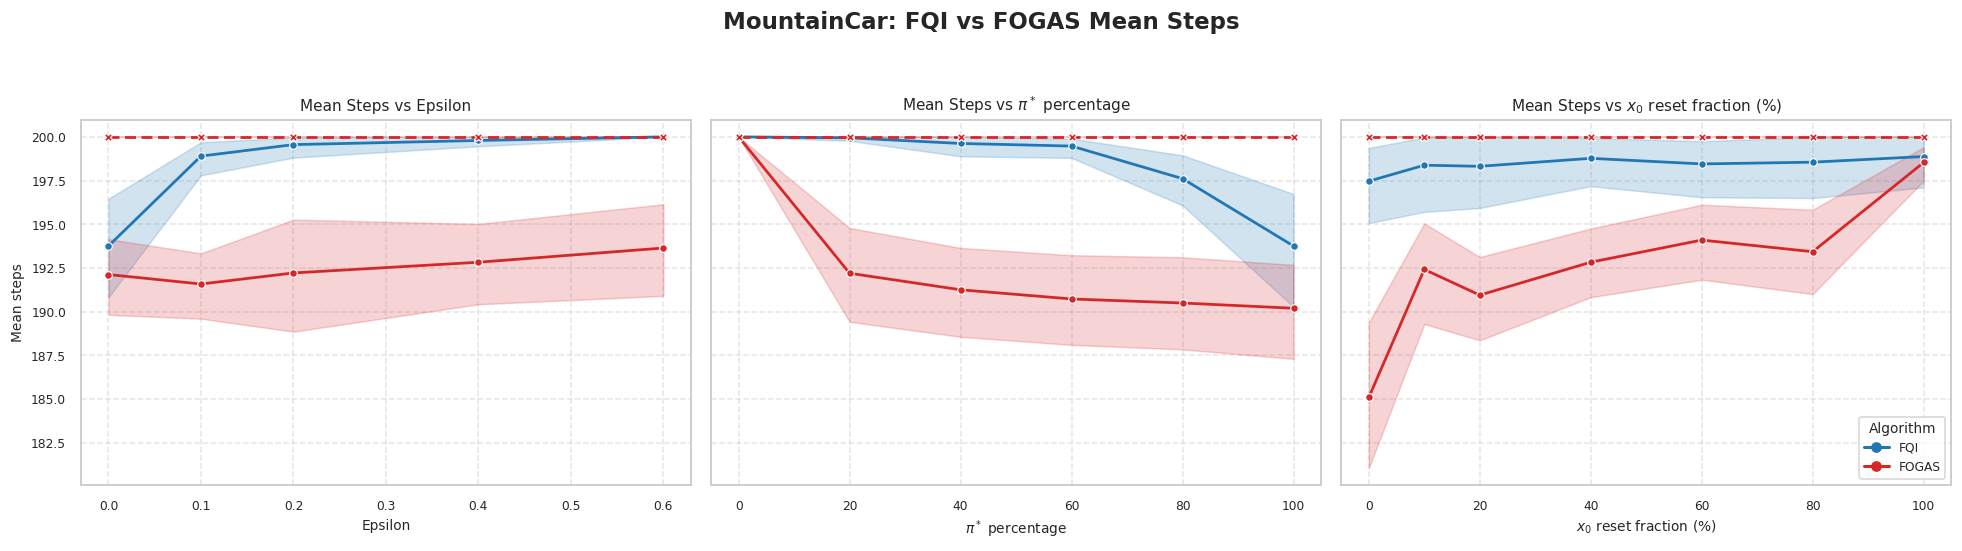

In [6]:
# ── Load MountainCar FQI + FOGAS Results ──────────────────────────────────────
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

csv_path = RESULTS_DIR / "grids" / "grid_mountaincar.csv"
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} rows from: {csv_path}")
display(df.head())

if "status" in df.columns:
    df = df[df["status"].isin(["ok", "partial_error"])].copy()

def parse_x0_fraction(name):
    m = re.match(r"x0_(\d+)_custom_(\d+)", str(name))
    return int(m.group(1)) / 100 if m else np.nan

def ok_mask(frame, status_col):
    if status_col in frame.columns:
        return frame[status_col].eq("ok")
    return pd.Series(True, index=frame.index)

df["x0_fraction"] = df["reset_name"].map(parse_x0_fraction)
df["pi_star_percentage"] = df["policy_fraction"] * 100
df["x0_percentage"] = df["x0_fraction"] * 100

plot_parts = []

if "fogas_greedy_mean_steps" in df.columns:
    fogas_greedy = df[ok_mask(df, "fogas_status")].copy()
    fogas_greedy["algorithm"] = "FOGAS"
    fogas_greedy["curve"] = "FOGAS greedy"
    fogas_greedy["mean_steps"] = fogas_greedy["fogas_greedy_mean_steps"]
    plot_parts.append(fogas_greedy)

if "fogas_solver_mean_steps" in df.columns:
    fogas_sampled = df[ok_mask(df, "fogas_status")].copy()
    fogas_sampled["algorithm"] = "FOGAS"
    fogas_sampled["curve"] = "FOGAS sampled"
    fogas_sampled["mean_steps"] = fogas_sampled["fogas_solver_mean_steps"]
    plot_parts.append(fogas_sampled)

if "fqi_mean_steps" in df.columns:
    fqi = df[ok_mask(df, "fqi_status")].copy()
    fqi["algorithm"] = "FQI"
    fqi["curve"] = "FQI greedy"
    fqi["mean_steps"] = fqi["fqi_mean_steps"]
    plot_parts.append(fqi)

df_plot = pd.concat(plot_parts, ignore_index=True)

print("Plotted rows per curve:")
display(df_plot["curve"].value_counts())

display(df_plot[[
    "curve",
    "epsilon",
    "pi_star_percentage",
    "x0_percentage",
    "mean_steps",
]].head())

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

x_specs = [
    ("epsilon", "Epsilon"),
    ("pi_star_percentage", r"$\pi^*$ percentage"),
    ("x0_percentage", r"$x_0$ reset fraction (%)"),
]

palette = {
    "FQI greedy": "#1f77b4",
    "FOGAS greedy": "#d62728",
    "FOGAS sampled": "#d62728",
}

curve_order = ["FQI greedy", "FOGAS greedy", "FOGAS sampled"]

fig, axes = plt.subplots(1, len(x_specs), figsize=(18, 4.8), sharey=True)

fig.suptitle(
    "MountainCar: FQI vs FOGAS Mean Steps",
    fontsize=15,
    fontweight="bold",
    y=1.04,
)

for ax, (x_var, x_label) in zip(axes, x_specs):
    sns.lineplot(
        data=df_plot,
        x=x_var,
        y="mean_steps",
        hue="curve",
        hue_order=curve_order,
        style="curve",
        style_order=curve_order,
        palette=palette,
        markers={
            "FQI greedy": "o",
            "FOGAS greedy": "o",
            "FOGAS sampled": "X",
        },
        dashes={
            "FQI greedy": "",
            "FOGAS greedy": "",
            "FOGAS sampled": (4, 2),
        },
        markersize=5,
        linewidth=1.8,
        errorbar=("ci", 95),
        legend=False,
        ax=ax,
    )

    ax.set_title(f"Mean Steps vs {x_label}", fontsize=10, pad=6)
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel("Mean steps" if ax is axes[0] else "", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

legend_handles = [
    Line2D([0], [0], color="#1f77b4", lw=2, marker="o", label="FQI"),
    Line2D([0], [0], color="#d62728", lw=2, marker="o", label="FOGAS"),
]

axes[-1].legend(
    handles=legend_handles,
    title="Algorithm",
    fontsize=8,
    title_fontsize=9,
)

plt.tight_layout()
plt.show()